# Step 3: Model Training & Comparison

Train and compare Random Forest, XGBoost, and SVR models for binding affinity prediction.
Use cross-validation for hyperparameter tuning and evaluate with R², RMSE, and Pearson r.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../models', exist_ok=True)

# Load data
X = pd.read_csv('../data/processed/features.csv')
target = pd.read_csv('../data/processed/target.csv')
y = target['pchembl_value'].values

print(f"Features: {X.shape}")
print(f"Target: {y.shape}, range: [{y.min():.2f}, {y.max():.2f}]")

Features: (10413, 2060)
Target: (10413,), range: [4.00, 11.00]


## 3.1 Train/Test Split

In [2]:
# Stratified split by binned pChEMBL values
y_binned = pd.cut(y, bins=5, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_binned
)

print(f"Training set: {X_train.shape[0]} compounds")
print(f"Test set: {X_test.shape[0]} compounds")
print(f"Train pChEMBL mean: {y_train.mean():.2f}, Test pChEMBL mean: {y_test.mean():.2f}")

# Scale features for SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')

Training set: 8330 compounds
Test set: 2083 compounds
Train pChEMBL mean: 6.96, Test pChEMBL mean: 6.95


['../models/scaler.pkl']

## 3.2 Random Forest

In [3]:
rf_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf, rf_params, n_iter=30, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_
print(f"\nBest RF params: {rf_search.best_params_}")
print(f"Best CV R²: {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV R²: 0.6977


## 3.3 XGBoost

In [4]:
xgb_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
xgb_search = RandomizedSearchCV(
    xgb_model, xgb_params, n_iter=30, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)

xgb_best = xgb_search.best_estimator_
print(f"\nBest XGB params: {xgb_search.best_params_}")
print(f"Best CV R²: {xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGB params: {'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV R²: 0.7201


## 3.4 Support Vector Regression

In [5]:
svr_params = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.2],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

svr = SVR()
svr_search = RandomizedSearchCV(
    svr, svr_params, n_iter=20, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)
svr_search.fit(X_train_scaled, y_train)

svr_best = svr_search.best_estimator_
print(f"\nBest SVR params: {svr_search.best_params_}")
print(f"Best CV R²: {svr_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best SVR params: {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.01, 'C': 10}
Best CV R²: 0.6749


## 3.5 Model Comparison

In [6]:
def evaluate_model(model, X_test, y_test, name):
    """Evaluate a model and return metrics."""
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pearson_r, pearson_p = stats.pearsonr(y_test, y_pred)
    return {
        'Model': name,
        'R²': r2,
        'RMSE': rmse,
        'Pearson r': pearson_r,
        'p-value': pearson_p,
        'predictions': y_pred
    }

# Evaluate all models
results = []
results.append(evaluate_model(rf_best, X_test, y_test, 'Random Forest'))
results.append(evaluate_model(xgb_best, X_test, y_test, 'XGBoost'))
results.append(evaluate_model(svr_best, X_test_scaled, y_test, 'SVR'))

# Display comparison table
metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'predictions'} for r in results])
metrics_df = metrics_df.round(4)
print("\n" + "="*60)
print("MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)


MODEL COMPARISON - TEST SET PERFORMANCE
        Model     R²   RMSE  Pearson r  p-value
Random Forest 0.7111 0.6993     0.8500      0.0
      XGBoost 0.7357 0.6689     0.8577      0.0
          SVR 0.6866 0.7283     0.8287      0.0


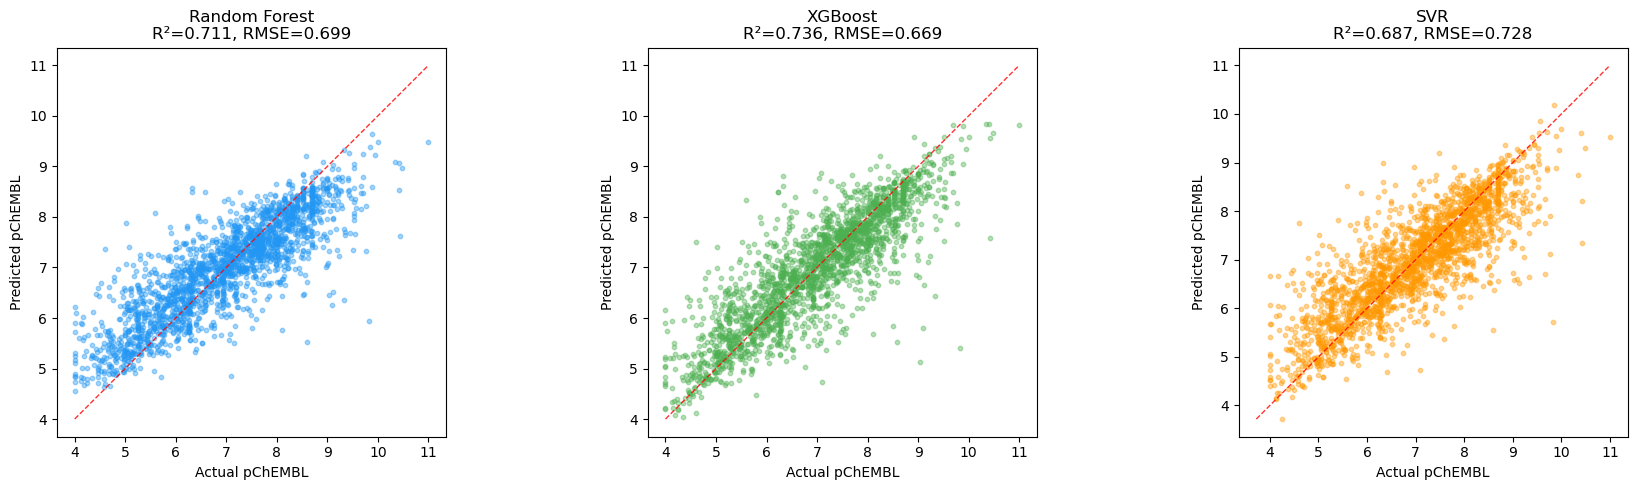

In [7]:
# Scatter plots: Predicted vs Actual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, result in enumerate(results):
    ax = axes[i]
    y_pred = result['predictions']
    ax.scatter(y_test, y_pred, alpha=0.4, s=10, color=colors[i])
    
    # Perfect prediction line
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', alpha=0.8, linewidth=1)
    
    ax.set_xlabel('Actual pChEMBL')
    ax.set_ylabel('Predicted pChEMBL')
    ax.set_title(f"{result['Model']}\nR²={result['R²']:.3f}, RMSE={result['RMSE']:.3f}")
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Save Best Model

In [8]:
# Identify and save the best model
best_idx = np.argmax([r['R²'] for r in results])
best_model_name = results[best_idx]['Model']
print(f"Best model: {best_model_name} (R²={results[best_idx]['R²']:.4f})")

models = {'Random Forest': rf_best, 'XGBoost': xgb_best, 'SVR': svr_best}
best_model = models[best_model_name]

# Save all models
for name, model in models.items():
    filename = name.lower().replace(' ', '_')
    joblib.dump(model, f'../models/{filename}.pkl')

# Save best model separately
joblib.dump(best_model, '../models/best_model.pkl')

# Save model metadata
metadata = {
    'best_model': best_model_name,
    'best_r2': results[best_idx]['R²'],
    'best_rmse': results[best_idx]['RMSE'],
    'needs_scaling': best_model_name == 'SVR',
    'feature_columns': X.columns.tolist(),
    'n_features': X.shape[1],
    'n_train': len(X_train),
    'n_test': len(X_test)
}
joblib.dump(metadata, '../models/metadata.pkl')

# Save metrics table
metrics_df.to_csv('../models/model_comparison.csv', index=False)

print(f"\nAll models and metadata saved to models/ directory")
print(f"Feature columns count: {len(metadata['feature_columns'])}")

Best model: XGBoost (R²=0.7357)

All models and metadata saved to models/ directory
Feature columns count: 2060
